# Week 2
on week 2 my goal is to code a Bayesian Optimization for functions with multiple features



In [157]:

import numpy as np
import matplotlib.pyplot as plt
import math
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF



# Function 1
This function has 2 dimensions.

### Data preparation

Here we prepare the initial data provided

In [158]:
input = np.load('./../../data/initial_data/function_1/initial_inputs.npy')
output = np.load('./../../data/initial_data/function_1/initial_outputs.npy')
print(input)
print(output)
#print(input.shape)
#print(input.shape[1])
func_dimensions = input.shape[1]

[[0.31940389 0.76295937]
 [0.57432921 0.8798981 ]
 [0.73102363 0.73299988]
 [0.84035342 0.26473161]
 [0.65011406 0.68152635]
 [0.41043714 0.1475543 ]
 [0.31269116 0.07872278]
 [0.68341817 0.86105746]
 [0.08250725 0.40348751]
 [0.88388983 0.58225397]]
[ 1.32267704e-079  1.03307824e-046  7.71087511e-016  3.34177101e-124
 -3.60606264e-003 -2.15924904e-054 -2.08909327e-091  2.53500115e-040
  3.60677119e-081  6.22985647e-048]


Here we add the data provided with the weekly queries

In [159]:
inputWeek1 = np.array([0.5, 0.5])
outputWeek1 = 2.6752879910742468e-09

input = np.append(input, [[inputWeek1[0], inputWeek1[1]]], axis=0)
output = np.append(output, outputWeek1)

print(input)
print(output)

[[0.31940389 0.76295937]
 [0.57432921 0.8798981 ]
 [0.73102363 0.73299988]
 [0.84035342 0.26473161]
 [0.65011406 0.68152635]
 [0.41043714 0.1475543 ]
 [0.31269116 0.07872278]
 [0.68341817 0.86105746]
 [0.08250725 0.40348751]
 [0.88388983 0.58225397]
 [0.5        0.5       ]]
[ 1.32267704e-079  1.03307824e-046  7.71087511e-016  3.34177101e-124
 -3.60606264e-003 -2.15924904e-054 -2.08909327e-091  2.53500115e-040
  3.60677119e-081  6.22985647e-048  2.67528799e-009]


# Data exploration
Here we plot the available datapoints for functions with 2 dimensions

TODO: include the values in the scatterplot

[np.float64(0.31940388883889725), np.float64(0.5743292145098291), np.float64(0.7310236309563586), np.float64(0.8403534169072556), np.float64(0.6501140597987644), np.float64(0.41043713662518566), np.float64(0.31269115679477755), np.float64(0.6834181688515067), np.float64(0.08250725182080587), np.float64(0.8838898288181171), np.float64(0.5)]
[np.float64(0.7629593742689353), np.float64(0.879898104984359), np.float64(0.7329998764152272), np.float64(0.26473161399676703), np.float64(0.6815263520602101), np.float64(0.14755429902998185), np.float64(0.07872277794971883), np.float64(0.8610574643936101), np.float64(0.403487506426324), np.float64(0.5822539743824439), np.float64(0.5)]
[ 1.32267704e-079  1.03307824e-046  7.71087511e-016  3.34177101e-124
 -3.60606264e-003 -2.15924904e-054 -2.08909327e-091  2.53500115e-040
  3.60677119e-081  6.22985647e-048  2.67528799e-009]


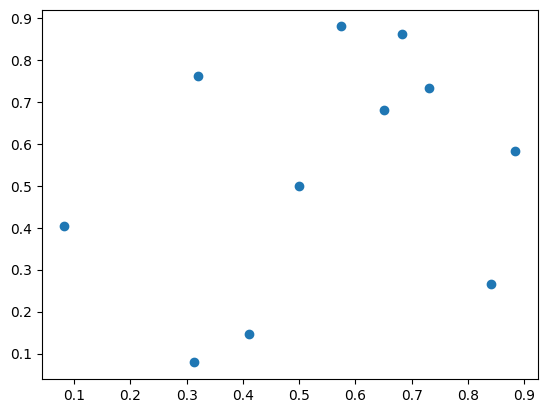

In [160]:
x = []
y = []
for i in input:
  x.append(i[0])
  y.append(i[1])

print(x)
print(y)
print(output)
plt.scatter(x,y)
plt.show()

# Bayesian Optimisation approach
We approach the study of this function with the Bayesian Optimisation
using and adaptation of the UCB acquisition function from required assignment 12.1

In [161]:
print(input)
print(input.shape)
print(np.array(input))

[[0.31940389 0.76295937]
 [0.57432921 0.8798981 ]
 [0.73102363 0.73299988]
 [0.84035342 0.26473161]
 [0.65011406 0.68152635]
 [0.41043714 0.1475543 ]
 [0.31269116 0.07872278]
 [0.68341817 0.86105746]
 [0.08250725 0.40348751]
 [0.88388983 0.58225397]
 [0.5        0.5       ]]
(11, 2)
[[0.31940389 0.76295937]
 [0.57432921 0.8798981 ]
 [0.73102363 0.73299988]
 [0.84035342 0.26473161]
 [0.65011406 0.68152635]
 [0.41043714 0.1475543 ]
 [0.31269116 0.07872278]
 [0.68341817 0.86105746]
 [0.08250725 0.40348751]
 [0.88388983 0.58225397]
 [0.5        0.5       ]]


# Preparation of the exploration space
Here we prepare the exploration space of the function<br>
The values are increments of 0.01 bounded between 0 and 1 (included) => 101 values for each dimension of the space<br>
dimension of the current function is stored in <b>func_dimensions</b>

In [201]:
#Initialise query lists and maximum observations
X, Y = input, output

#Initialise grid for plots
vector_values = np.linspace(0, 1, 101)# 101 values from 0 to 1
#print(vector_values)
x_grid = np.empty((1,func_dimensions))
#print(x_grid)
#getSpace(vector_values, func_dimensions)

for i in vector_values:
    for j in vector_values:
        x_grid = np.append(x_grid, [[i, j]], axis=0)
#x_grid = np.mgrid[0:1:0.01, 0:1:0.01]
#x_grid = np.array(np.meshgrid(vector_values, vector_values))
x_grid = np.delete(x_grid, 0, axis=0)
print(x_grid)
print(x_grid.shape)


[[0.   0.  ]
 [0.   0.01]
 [0.   0.02]
 ...
 [1.   0.98]
 [1.   0.99]
 [1.   1.  ]]
(10201, 2)


In [202]:
print(Y)
print(np.array(Y).reshape(-1, 1))
print(np.array(Y))

[ 1.32267704e-079  1.03307824e-046  7.71087511e-016  3.34177101e-124
 -3.60606264e-003 -2.15924904e-054 -2.08909327e-091  2.53500115e-040
  3.60677119e-081  6.22985647e-048  2.67528799e-009]
[[ 1.32267704e-079]
 [ 1.03307824e-046]
 [ 7.71087511e-016]
 [ 3.34177101e-124]
 [-3.60606264e-003]
 [-2.15924904e-054]
 [-2.08909327e-091]
 [ 2.53500115e-040]
 [ 3.60677119e-081]
 [ 6.22985647e-048]
 [ 2.67528799e-009]]
[ 1.32267704e-079  1.03307824e-046  7.71087511e-016  3.34177101e-124
 -3.60606264e-003 -2.15924904e-054 -2.08909327e-091  2.53500115e-040
  3.60677119e-081  6.22985647e-048  2.67528799e-009]


# Bayesian Optimisation with UCB applied

In [204]:
rbf_lengthscale = [0.1, 0.1]
real_noise_std = 1e-10
noise_assumption = 1e-10

#Define kernel of GP
kernel = RBF(length_scale=rbf_lengthscale, length_scale_bounds='fixed')

model = GaussianProcessRegressor(kernel = kernel)
#Fit the model
model.fit(np.array(X), np.array(Y).reshape(-1, 1))


#Calculate the mean and standard deviation and make them one-dimensional for plotting
post_mean, post_std = model.predict(x_grid, return_std=True)

#Acquisition function parameter
beta = 1.96
#beta = 0.5

acquisition_function = post_mean + beta * post_std

grid = x_grid.squeeze()
obs = grid[np.argmax(acquisition_function)] #Else use the acquisition function

print('Next observation: ', obs)
#print (obs)


Next observation:  [0. 1.]


# Plottings

In [119]:
post_mean, post_std = post_mean.squeeze(), post_std.squeeze()
print(post_mean)
print(len(post_mean))
print(post_std)
print(len(post_std))


[1.62786896e-09 1.74553073e-09 1.85144078e-09 ... 2.36822061e-06
 1.55857933e-06 9.51083162e-07]
10201
[0.99998018 0.99997702 0.99997388 ... 0.99999234 0.99999402 0.9999954 ]
10201


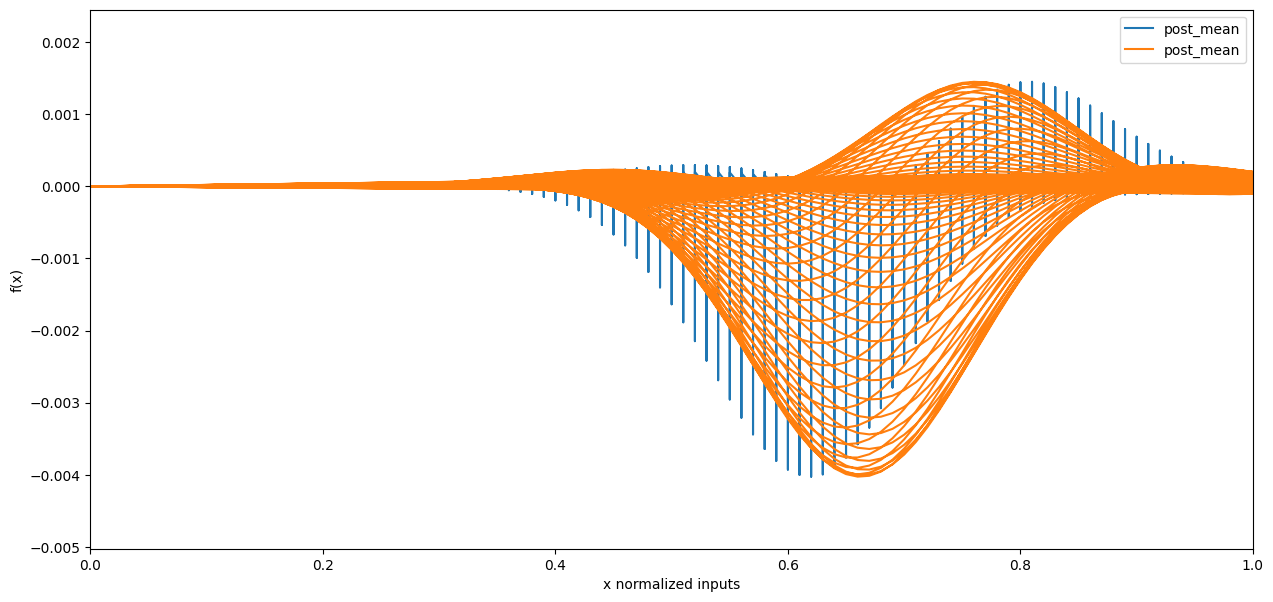

In [120]:
max_obs = 0
max_obs = max(max_obs, max(acquisition_function))

#Initialise plots
fig, ax = plt.subplots(figsize = (15, 7))
#Set the x and y limits, labels and dynamic title
ax.set_xlim(0, 1)
ax.set_ylim(min(post_mean) - 0.001, max(post_mean) + 0.001)
ax.set_ylabel('f(x)')
ax.set_xlabel('x normalized inputs')
#Plot queries
#ax.scatter(X, Y, c = 'r', marker='x', s = 100)
#ax.scatter(x_grid.squeeze(), post_mean, c = 'r', marker='.', s = 100)

#Plot the mean and standard deviation
ax.plot(x_grid, post_mean,  label = 'post_mean')
#ax.plot(x_grid, post_std,  label = 'post_std')
#ax.plot(x_grid.squeeze(), post_mean, label = 'GP Posterior Mean')
#ax.fill_between(x_grid.squeeze(), post_mean - beta*post_std, post_mean + beta*post_std, alpha = 0.2, label = str(beta) + ' Standard Deviations')
ax.legend()
#plt.show()



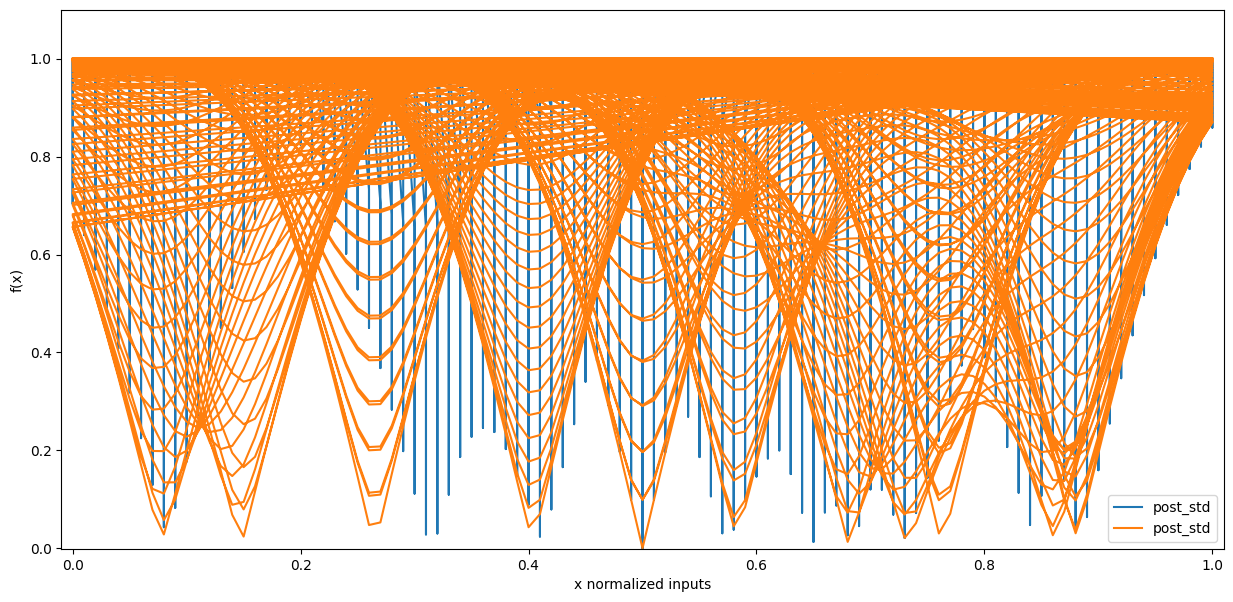

In [121]:
max_obs = 0
max_obs = max(max_obs, max(acquisition_function))

#Initialise plots
fig, ax = plt.subplots(figsize = (15, 7))
#Set the x and y limits, labels and dynamic title
ax.set_xlim(-0.01, 1.01)
ax.set_ylim(min(post_std) - 0.001, max(post_std) + 0.1)
ax.set_ylabel('f(x)')
ax.set_xlabel('x normalized inputs')
#Plot queries
#ax.scatter(X, Y, c = 'r', marker='x', s = 100)
#ax.scatter(x_grid.squeeze(), post_mean, c = 'r', marker='.', s = 100)

#Plot the mean and standard deviation
#ax.plot(x_grid, post_mean,  label = 'post_mean')
ax.plot(x_grid, post_std,  label = 'post_std')
#ax.plot(x_grid.squeeze(), post_mean, label = 'GP Posterior Mean')
#ax.fill_between(x_grid.squeeze(), post_mean - beta*post_std, post_mean + beta*post_std, alpha = 0.2, label = str(beta) + ' Standard Deviations')
ax.legend()
#plt.show()



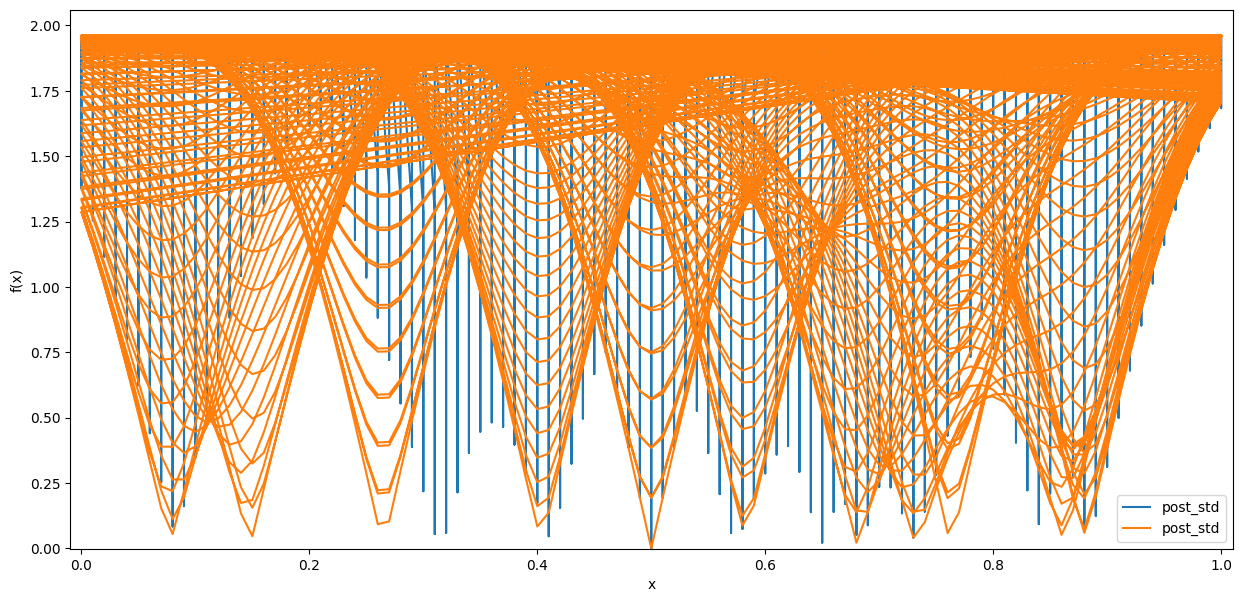

In [122]:
max_obs = 0
max_obs = max(max_obs, max(acquisition_function))

#Initialise plots
fig, ax = plt.subplots(figsize = (15, 7))
#Set the x and y limits, labels and dynamic title
ax.set_xlim(-0.01, 1.01)
ax.set_ylim(min(acquisition_function) - 0.001, max(acquisition_function) + 0.1)
ax.set_ylabel('f(x)')
ax.set_xlabel('x')
#Plot queries
#ax.scatter(X, Y, c = 'r', marker='x', s = 100)
#ax.scatter(x_grid.squeeze(), post_mean, c = 'r', marker='.', s = 100)

#Plot the mean and standard deviation
#ax.plot(x_grid, post_mean,  label = 'post_mean')
ax.plot(x_grid, acquisition_function,  label = 'post_std')
#ax.plot(x_grid.squeeze(), post_mean, label = 'GP Posterior Mean')
#ax.fill_between(x_grid.squeeze(), post_mean - beta*post_std, post_mean + beta*post_std, alpha = 0.2, label = str(beta) + ' Standard Deviations')
ax.legend()
#plt.show()

